In [ ]:
#---------------------------------------------------------------import statements required-----------------------------------------------------------------------------------------------------

import pandas as pd #used for data processing and file reading
import  matplotlib as plt #used for visualization 
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np #used for linear algebra
import sklearn as sk #used for linear regression model
import statsmodels.api as sm #used for regression diagnostics
from xgboost import XGBRegressor as xgb #used for gradient boosted regression method
import seaborn as sb # used for visualization
#----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
#pip install pandas matplotlib numpy scikit-learn statsmodels xgboost seaborn

Mean Absolute Error: 2594.13
R2 Score: 0.866


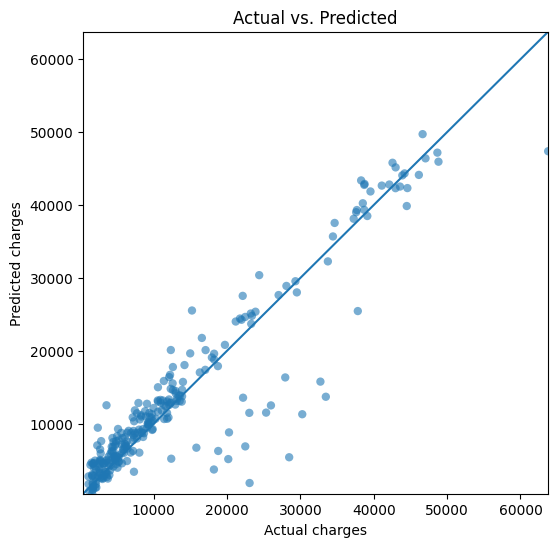

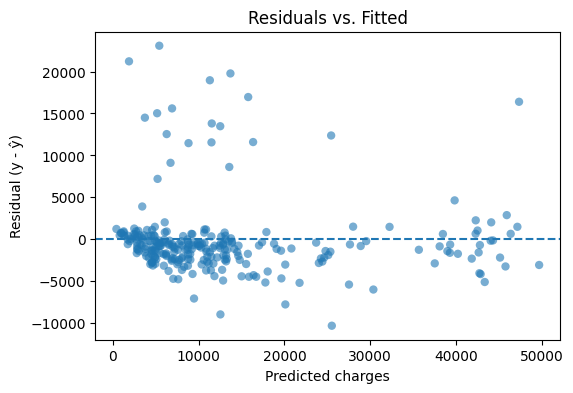

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
import pandas as pd 
import  matplotlib as plt 
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np 
import sklearn as sk 
import statsmodels.api as sm 
from xgboost import XGBRegressor as xgb 
import seaborn as sb
#----------------------------------------------------------------------XGB Method--------------------------------------------------------------------------------------------------------------

data = pd.read_csv("../csv/insurance.csv")

x = data.drop("charges",axis=1)
y = data["charges"]

x_train,x_test, y_train, y_test= sk.model_selection.train_test_split(x,y,test_size=0.2, random_state=42)

cat =["sex","smoker","region"]
num = ["age","bmi","children"]

preprocessor = sk.compose.ColumnTransformer([("cat", sk.preprocessing.OneHotEncoder(handle_unknown="ignore"),cat)],remainder="passthrough")

model = xgb(n_estimators=500, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8, random_state=42)

pipeline = sk.pipeline.Pipeline(steps=[("preprocessor",preprocessor),("model",model)])

pipeline.fit(x_train,y_train)

y_pred = pipeline.predict(x_test)

mae=sk.metrics.mean_absolute_error(y_test,y_pred)
r2=sk.metrics.r2_score(y_test,y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"R2 Score: {r2:.3f}")



#----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

#----------------------------------------------------------------------------visualizations----------------------------------------------------------------------------------------------------


plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolor="none")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual charges")
plt.ylabel("Predicted charges")
plt.title("Actual vs. Predicted")
plt.show()


residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.6, edgecolor="none")
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted charges")
plt.ylabel("Residual (y - ŷ)")
plt.title("Residuals vs. Fitted")
plt.show()


sk.set_config(display="diagram")
pipeline

In [ ]:
# attempted master script 
import pandas as pd 
import  matplotlib as plt 
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np 
import sklearn as sk 
import statsmodels.api as sm 
from xgboost import XGBRegressor as xgb 
import seaborn as sb

#---------------------------------------------Configuration for input-----------------------------------------------

REQUIRED_COLS = ["age", "sex", "bmi", "children", "smoker", "region", "charges"]
VALID_SEX     = {"male": "male", "m": "male", "female": "female", "f": "female"}
VALID_SMOKER  = {"yes": "yes", "y": "yes", "true": "yes", "1": "yes",
                 "no": "no", "n": "no", "false": "no", "0": "no"}
VALID_REGION  = {"southwest":"southwest","southeast":"southeast",
                 "northwest":"northwest","northeast":"northeast",
                 "sw":"southwest","se":"southeast","nw":"northwest","ne":"northeast"}

#------------------------------------------------------------------------------------------------------------------------

data=pd.read_csv("../csv/insurance.csv")

#------------------------------------------Utility Functions----------------------------------------------------------------

def _iqr_winsorize(series: pd.Series, low_q=0.01, high_q=0.99) -> pd.Series:
    """Clip extreme tails at given quantiles (simple robust cap)."""
    lo, hi = series.quantile([low_q, high_q]).values
    return series.clip(lo, hi)

def _coerce_numeric(df: pd.DataFrame, cols) -> pd.DataFrame:
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def _strip_lower(s: pd.Series) -> pd.Series:
    return s.astype(str).str.strip().str.lower()

def _normalize_map(s: pd.Series, mapping: dict, default=np.nan) -> pd.Series:
    return _strip_lower(s).map(mapping).fillna(default)

def validate_schema(df: pd.DataFrame):
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

def basic_quality_report(df: pd.DataFrame) -> pd.DataFrame:
    num = df.select_dtypes(include=np.number)
    rep = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_missing": df.isna().sum(),
        "n_unique": df.nunique()
    })
    # add numeric min/max where applicable
    rep["min"] = pd.Series({c: num[c].min() for c in num.columns})
    rep["max"] = pd.Series({c: num[c].max() for c in num.columns})
    return rep

